# 01 — EDA Olist Delivery-Risk

Exploration **jetable** — pas de feature engineering, pas de modèle.  
Objectif : comprendre la population, le taux de retard `is_late`, et les premiers signaux pour orienter le feature engineering.

## Section 0 — Setup & Chargement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

RAW = Path('../data/raw')

# Olist stocke toutes les dates en texte — parse_dates les convertit au chargement.
# Sans ca, les calculs de delai (.dt.days) levent TypeError silencieusement.
date_cols_orders = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]

orders    = pd.read_csv(RAW / 'olist_orders_dataset.csv',      parse_dates=date_cols_orders)
items     = pd.read_csv(RAW / 'olist_order_items_dataset.csv', parse_dates=['shipping_limit_date'])
payments  = pd.read_csv(RAW / 'olist_order_payments_dataset.csv')
reviews   = pd.read_csv(RAW / 'olist_order_reviews_dataset.csv',
                        parse_dates=['review_creation_date', 'review_answer_timestamp'])
customers = pd.read_csv(RAW / 'olist_customers_dataset.csv')
products  = pd.read_csv(RAW / 'olist_products_dataset.csv')
sellers   = pd.read_csv(RAW / 'olist_sellers_dataset.csv')
geo       = pd.read_csv(RAW / 'olist_geolocation_dataset.csv')

print('Shapes des tables :')
tables = [
    ('orders', orders), ('items', items), ('payments', payments),
    ('reviews', reviews), ('customers', customers),
    ('products', products), ('sellers', sellers), ('geo', geo),
]
for name, df in tables:
    print(f'  {name:12s} : {df.shape[0]:>7,} lignes  x  {df.shape[1]} colonnes')

Shapes des tables :
  orders       :  99,441 lignes  x  8 colonnes
  items        : 112,650 lignes  x  7 colonnes
  payments     : 103,886 lignes  x  5 colonnes
  reviews      :  99,224 lignes  x  7 colonnes
  customers    :  99,441 lignes  x  5 colonnes
  products     :  32,951 lignes  x  9 colonnes
  sellers      :   3,095 lignes  x  4 colonnes
  geo          : 1,000,163 lignes  x  5 colonnes


## Section 1 — Volumétrie

In [2]:
n_total = len(orders)
print(f'Commandes totales : {n_total:,}')
print()
print('Repartition order_status :')
print(orders['order_status'].value_counts().to_string())
print()

delivered = orders[orders['order_status'] == 'delivered'].copy()
n_delivered = len(delivered)
print(f'Commandes delivered : {n_delivered:,}  ({n_delivered / n_total:.1%} du total)')
print()

n_with_date   = delivered['order_delivered_customer_date'].notna().sum()
n_missing_date = n_delivered - n_with_date
print(f'  avec order_delivered_customer_date non nulle : {n_with_date:,}')
print(f'  sans date de livraison reelle (inutilisables) : {n_missing_date:,}  ({n_missing_date / n_delivered:.1%})')
print()
print('-> Implication : population de travail = delivered + date reelle non nulle.')
print('   Les sans-date sont exclues avant calcul de is_late. Volume a noter dans le README.')

Commandes totales : 99,441

Repartition order_status :
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2

Commandes delivered : 96,478  (97.0% du total)

  avec order_delivered_customer_date non nulle : 96,470
  sans date de livraison reelle (inutilisables) : 8  (0.0%)

-> Implication : population de travail = delivered + date reelle non nulle.
   Les sans-date sont exclues avant calcul de is_late. Volume a noter dans le README.


## Section 2 — Taux de retard `is_late`

> **Chiffre fondateur** — il détermine le déséquilibre de classes, le choix de métrique et la stratégie de rééchantillonnage.

   TAUX DE RETARD  :  8.1%   (7,826 / 96,470)



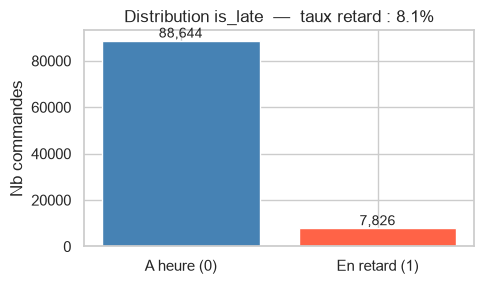


-> Implication (regle de lecture) :
   < 10 % : fort desequilibre -> class_weight="balanced" ou SMOTE obligatoire, privilegier PR-AUC
   10-30 % : desequilibre modere -> class_weight suffit, F1 / PR-AUC restent prioritaires sur Accuracy
   > 30 % : presque equilibre -> moins de pression sur le reechantillonnage


In [3]:
# Population de base : delivered + date reelle non nulle + date estimee non nulle
pop = delivered.dropna(
    subset=['order_delivered_customer_date', 'order_estimated_delivery_date']
).copy()
n_pop = len(pop)

pop['is_late'] = (
    pop['order_delivered_customer_date'] > pop['order_estimated_delivery_date']
).astype(int)

n_late      = pop['is_late'].sum()
taux_retard = pop['is_late'].mean()

print('=' * 58)
print(f'   TAUX DE RETARD  :  {taux_retard:.1%}   ({n_late:,} / {n_pop:,})')
print('=' * 58)
print()

fig, ax = plt.subplots(figsize=(5, 3))
counts = pop['is_late'].value_counts().sort_index()
labels = ['A heure (0)', 'En retard (1)']
bars   = ax.bar(labels, counts.values, color=['steelblue', 'tomato'], edgecolor='white')
for bar, val in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f'{val:,}',
        ha='center', va='bottom', fontsize=10,
    )
ax.set_title(f'Distribution is_late  —  taux retard : {taux_retard:.1%}', fontsize=12)
ax.set_ylabel('Nb commandes')
plt.tight_layout()
plt.show()

print()
print('-> Implication (regle de lecture) :')
print('   < 10 % : fort desequilibre -> class_weight="balanced" ou SMOTE obligatoire, privilegier PR-AUC')
print('   10-30 % : desequilibre modere -> class_weight suffit, F1 / PR-AUC restent prioritaires sur Accuracy')
print('   > 30 % : presque equilibre -> moins de pression sur le reechantillonnage')

## Section 3 — Grain des tables secondaires

In [4]:
print(f'Reference : {n_pop:,} order_id distincts dans la population livree')
print()

for name, df in [('order_items', items), ('order_payments', payments), ('order_reviews', reviews)]:
    n_rows    = len(df)
    n_orders  = df['order_id'].nunique()
    ratio_moy = n_rows / n_orders
    max_par   = df.groupby('order_id').size().max()
    print(
        f'  {name:18s} : {n_rows:>7,} lignes | '
        f'{n_orders:>7,} order_id distincts | '
        f'ratio moy {ratio_moy:.2f} | max {max_par}/commande'
    )

print()
print('-> Implication : une jointure directe sur order_id multiplie les lignes.')
print('   Regle invariante : agreger (sum/mean/count) par order_id AVANT de joindre.')
print('   Exemple : sum(freight_value) et sum(price) dans items, avant merge sur orders.')

Reference : 96,470 order_id distincts dans la population livree

  order_items        : 112,650 lignes |  98,666 order_id distincts | ratio moy 1.14 | max 21/commande
  order_payments     : 103,886 lignes |  99,440 order_id distincts | ratio moy 1.04 | max 29/commande


  order_reviews      :  99,224 lignes |  98,673 order_id distincts | ratio moy 1.01 | max 3/commande

-> Implication : une jointure directe sur order_id multiplie les lignes.
   Regle invariante : agreger (sum/mean/count) par order_id AVANT de joindre.
   Exemple : sum(freight_value) et sum(price) dans items, avant merge sur orders.


## Section 4 — Incohérences temporelles

In [5]:
print(f'Population de reference : {n_pop:,} commandes')
print()

checks = [
    ('livraison reelle < achat',  pop['order_delivered_customer_date'] < pop['order_purchase_timestamp']),
    ('delai estime < achat',       pop['order_estimated_delivery_date'] < pop['order_purchase_timestamp']),
    ('approbation < achat',        pop['order_approved_at']             < pop['order_purchase_timestamp']),
]

for label, mask in checks:
    n   = mask.sum()
    pct = n / n_pop
    print(f'  {label:35s} : {n:>5,}  ({pct:.3%})')

print()

# Masque combine : exclure si livraison OU estimation est anterieure a l'achat
mask_inco = (
    (pop['order_delivered_customer_date'] < pop['order_purchase_timestamp']) |
    (pop['order_estimated_delivery_date'] < pop['order_purchase_timestamp'])
)
n_inco = mask_inco.sum()
print(f'  Total incoh. (union livraison OU estimation) : {n_inco:,}  ({n_inco / n_pop:.3%})')
print()
print('-> Implication : lignes avec timestamps corrompus (fuseaux horaires ? erreurs saisie ?).')
print('   Exclusion au moment du split. Volume a documenter dans README / section limites.')

Population de reference : 96,470 commandes

  livraison reelle < achat            :     0  (0.000%)
  delai estime < achat                :     0  (0.000%)
  approbation < achat                 :     0  (0.000%)

  Total incoh. (union livraison OU estimation) : 0  (0.000%)

-> Implication : lignes avec timestamps corrompus (fuseaux horaires ? erreurs saisie ?).
   Exclusion au moment du split. Volume a documenter dans README / section limites.


## Section 5 — Valeurs manquantes

In [6]:
print('=== orders — colonnes temporelles ===')
date_check = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
miss_orders = orders[date_check].isnull().sum()
pct_orders  = (miss_orders / len(orders) * 100).round(2)
print(pd.DataFrame({'n_null': miss_orders, 'pct': pct_orders}).to_string())

print()
print('=== products — categorie et dimensions ===')
prod_check = [
    'product_category_name',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
]
miss_prod = products[prod_check].isnull().sum()
pct_prod  = (miss_prod / len(products) * 100).round(2)
print(pd.DataFrame({'n_null': miss_prod, 'pct': pct_prod}).to_string())

print()
print('=== order_items — prix et fret ===')
miss_items = items[['price', 'freight_value']].isnull().sum()
pct_items  = (miss_items / len(items) * 100).round(2)
print(pd.DataFrame({'n_null': miss_items, 'pct': pct_items}).to_string())

print()
print('-> Implication :')
print('   < 1 % : manquant marginal -> imputation simple (mediane / mode)')
print('   1-5 % : a documenter dans README section limites')
print('   > 5 % : decision architecture requise (exclure la feature ou imputer avec justification)')

=== orders — colonnes temporelles ===
                               n_null   pct
order_purchase_timestamp            0  0.00
order_approved_at                 160  0.16
order_delivered_carrier_date     1783  1.79
order_delivered_customer_date    2965  2.98
order_estimated_delivery_date       0  0.00

=== products — categorie et dimensions ===
                       n_null   pct
product_category_name     610  1.85
product_weight_g            2  0.01
product_length_cm           2  0.01
product_height_cm           2  0.01
product_width_cm            2  0.01

=== order_items — prix et fret ===
               n_null  pct
price               0  0.0
freight_value       0  0.0

-> Implication :
   < 1 % : manquant marginal -> imputation simple (mediane / mode)
   1-5 % : a documenter dans README section limites
   > 5 % : decision architecture requise (exclure la feature ou imputer avec justification)


## Section 6 — Distributions des variables candidates

> `delay_real_days` (basé sur `order_delivered_customer_date`) est utilisé ici **uniquement en description statistique**.  
> Il **n'apparaîtra pas** comme variable explicative croisée avec `is_late` en Section 7 — discipline fuite.

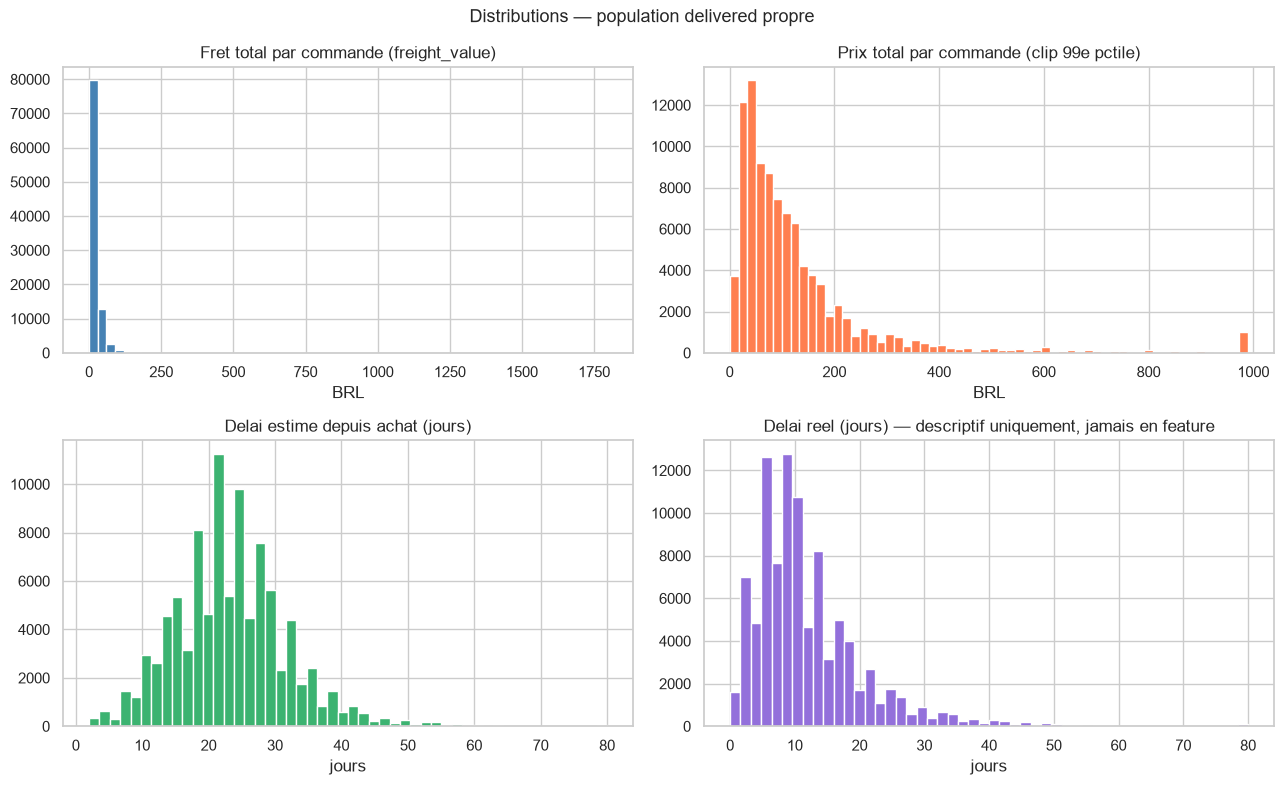

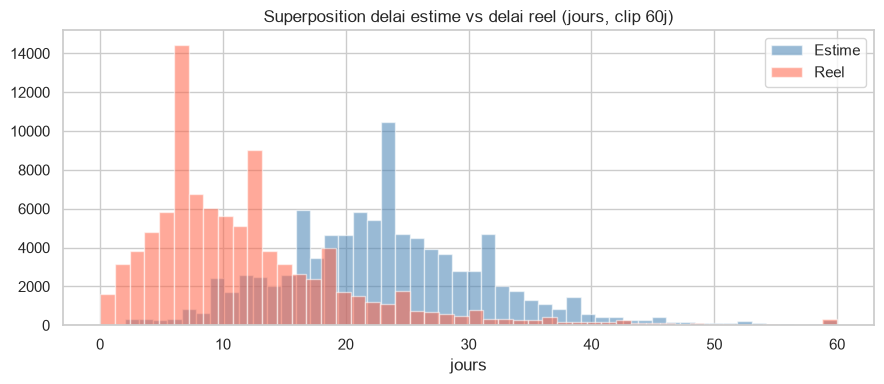

Statistiques descriptives :
       delay_estimated_days  delay_real_days  freight_total  price_total
count               96470.0          96470.0        96470.0      96470.0
mean                   23.4             12.1           22.8        137.0
std                     8.8              9.6           21.6        209.1
min                     2.0              0.0            0.0          0.8
25%                    18.0              6.0           13.8         45.9
50%                    23.0             10.0           17.2         86.5
75%                    28.0             15.0           24.0        149.9
max                   155.0            209.0         1795.0      13440.0

-> Implication :
   Queues longues sur fret/prix -> log-transformation probable en feature engineering.
   Ecart visible estime/reel sur superposition : le probleme de retard est systemique.


In [7]:
# Calcul des delais sur pop
pop['delay_estimated_days'] = (
    pop['order_estimated_delivery_date'] - pop['order_purchase_timestamp']
).dt.days

pop['delay_real_days'] = (
    pop['order_delivered_customer_date'] - pop['order_purchase_timestamp']
).dt.days

# Agregation items : 1 ligne par commande
items_agg = (
    items
    .groupby('order_id')
    .agg(freight_total=('freight_value', 'sum'), price_total=('price', 'sum'))
    .reset_index()
)
pop_enr = pop.merge(items_agg, on='order_id', how='left')

# --- 4 distributions individuelles ---
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].hist(pop_enr['freight_total'].dropna(), bins=60, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Fret total par commande (freight_value)')
axes[0, 0].set_xlabel('BRL')

p99_price = pop_enr['price_total'].quantile(0.99)
axes[0, 1].hist(
    pop_enr['price_total'].dropna().clip(upper=p99_price),
    bins=60, color='coral', edgecolor='white',
)
axes[0, 1].set_title('Prix total par commande (clip 99e pctile)')
axes[0, 1].set_xlabel('BRL')

axes[1, 0].hist(
    pop['delay_estimated_days'].dropna().clip(0, 80),
    bins=50, color='mediumseagreen', edgecolor='white',
)
axes[1, 0].set_title('Delai estime depuis achat (jours)')
axes[1, 0].set_xlabel('jours')

axes[1, 1].hist(
    pop['delay_real_days'].dropna().clip(0, 80),
    bins=50, color='mediumpurple', edgecolor='white',
)
axes[1, 1].set_title('Delai reel (jours) — descriptif uniquement, jamais en feature')
axes[1, 1].set_xlabel('jours')

plt.suptitle('Distributions — population delivered propre', fontsize=13)
plt.tight_layout()
plt.show()

# --- Superposition estime vs reel ---
fig, ax = plt.subplots(figsize=(9, 4))
pop['delay_estimated_days'].clip(0, 60).hist(
    ax=ax, bins=50, alpha=0.55, color='steelblue', label='Estime'
)
pop['delay_real_days'].clip(0, 60).hist(
    ax=ax, bins=50, alpha=0.55, color='tomato', label='Reel'
)
ax.set_title('Superposition delai estime vs delai reel (jours, clip 60j)')
ax.set_xlabel('jours')
ax.legend()
plt.tight_layout()
plt.show()

print('Statistiques descriptives :')
desc = pop_enr[['delay_estimated_days', 'delay_real_days', 'freight_total', 'price_total']]
print(desc.describe().round(1).to_string())
print()
print('-> Implication :')
print('   Queues longues sur fret/prix -> log-transformation probable en feature engineering.')
print('   Ecart visible estime/reel sur superposition : le probleme de retard est systemique.')

## Section 7 — Premier lien `is_late` × variables clés

> **Discipline fuite** — seul `delay_estimated_days` (connu à l'instant de l'achat) est croisé avec `is_late`.  
> `delay_real_days` n'est **pas** utilisé ici comme variable explicative.

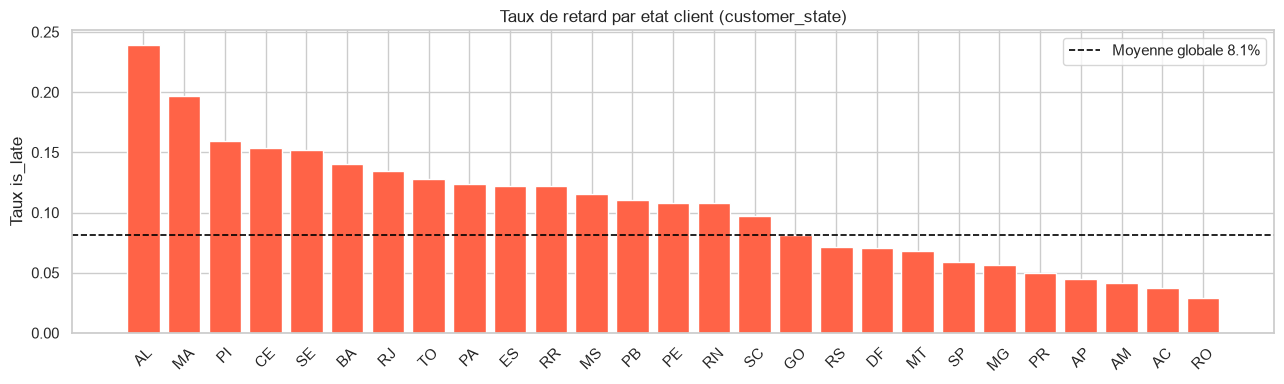

Top 5 etats avec le plus fort taux de retard :
                    taux     n
customer_state                
AL              0.239295   397
MA              0.196653   717
PI              0.159664   476
CE              0.153245  1279
SE              0.152239   335

-> Implication : si les etats varient significativement, customer_state porte un signal.
   A encoder (target encoding ou regroupement regional) en feature engineering.


In [8]:
# --- 7a : is_late x etat client ---
pop_cust = pop.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')

late_state = (
    pop_cust.groupby('customer_state')['is_late']
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'taux', 'count': 'n'})
            .sort_values('taux', ascending=False)
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(late_state.index, late_state['taux'], color='tomato')
ax.axhline(
    taux_retard, color='black', linestyle='--', linewidth=1.2,
    label=f'Moyenne globale {taux_retard:.1%}',
)
ax.set_title('Taux de retard par etat client (customer_state)')
ax.set_ylabel('Taux is_late')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Top 5 etats avec le plus fort taux de retard :')
print(late_state.head().to_string())
print()
print('-> Implication : si les etats varient significativement, customer_state porte un signal.')
print('   A encoder (target encoding ou regroupement regional) en feature engineering.')

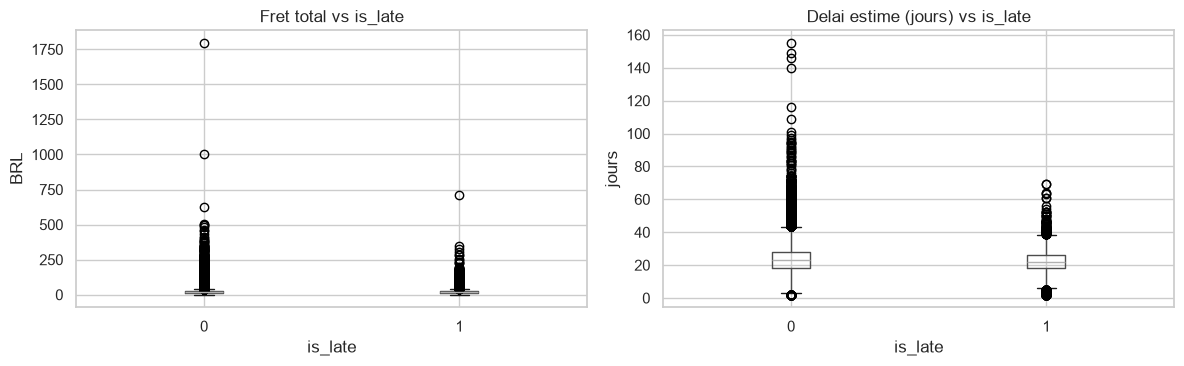

Mediane fret total par classe :
is_late
0    17.07
1    18.06

Mediane delai estime par classe :
is_late
0    23.0
1    22.0

-> Note discipline fuite : delay_estimated_days = connu a l achat -> autorise.
   delay_real_days = posterieur a l achat -> INTERDIT en feature et non croise ici.


In [9]:
# --- 7b : is_late x fret ---
pop_freight = pop_enr[['is_late', 'freight_total']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pop_freight.boxplot(column='freight_total', by='is_late', ax=axes[0])
axes[0].set_title('Fret total vs is_late')
axes[0].set_xlabel('is_late')
axes[0].set_ylabel('BRL')
plt.suptitle('')

# --- 7c : is_late x delai estime (SEUL delai autorise comme variable explicative) ---
pop[['delay_estimated_days', 'is_late']].dropna().boxplot(
    column='delay_estimated_days', by='is_late', ax=axes[1]
)
axes[1].set_title('Delai estime (jours) vs is_late')
axes[1].set_xlabel('is_late')
axes[1].set_ylabel('jours')
plt.suptitle('')
plt.tight_layout()
plt.show()

print('Mediane fret total par classe :')
print(pop_freight.groupby('is_late')['freight_total'].median().round(2).to_string())
print()
print('Mediane delai estime par classe :')
print(pop[['is_late', 'delay_estimated_days']].groupby('is_late')['delay_estimated_days'].median().round(1).to_string())
print()
print('-> Note discipline fuite : delay_estimated_days = connu a l achat -> autorise.')
print('   delay_real_days = posterieur a l achat -> INTERDIT en feature et non croise ici.')

Couverture geo : 99.5% des commandes ont une distance calculable



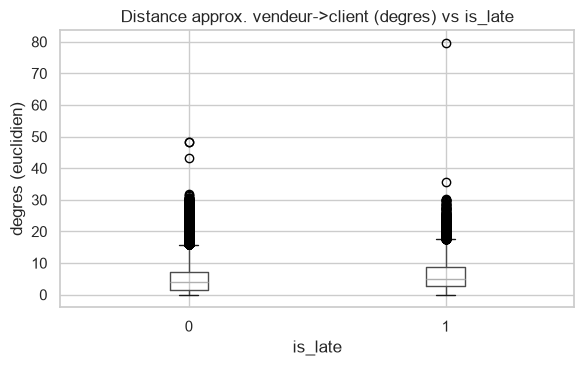

Mediane distance par classe :
is_late
0    4.019
1    4.840

-> Implication : si medianes differentes -> distance = signal utile.
   En feature engineering : convertir en km (Haversine), aggreger si multi-vendeurs.


In [10]:
# --- 7d : is_late x distance approx. vendeur->client ---
# Point moyen par prefixe postal — pas de nettoyage fin des aberrations (EDA only)
geo_mean = (
    geo
    .groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']]
    .mean()
    .reset_index()
    .rename(columns={
        'geolocation_zip_code_prefix': 'zip_prefix',
        'geolocation_lat': 'lat',
        'geolocation_lng': 'lng',
    })
)

cust_geo = (
    customers[['customer_id', 'customer_zip_code_prefix']]
    .merge(geo_mean, left_on='customer_zip_code_prefix', right_on='zip_prefix', how='left')
    .rename(columns={'lat': 'cust_lat', 'lng': 'cust_lng'})
    [['customer_id', 'cust_lat', 'cust_lng']]
)

sell_geo = (
    sellers[['seller_id', 'seller_zip_code_prefix']]
    .merge(geo_mean, left_on='seller_zip_code_prefix', right_on='zip_prefix', how='left')
    .rename(columns={'lat': 'sell_lat', 'lng': 'sell_lng'})
    [['seller_id', 'sell_lat', 'sell_lng']]
)

# Un seul vendeur par commande (premier item — simplification EDA)
first_seller = items[['order_id', 'seller_id']].drop_duplicates(subset='order_id')

pop_geo = (
    pop[['order_id', 'customer_id', 'is_late']]
    .merge(cust_geo,     on='customer_id', how='left')
    .merge(first_seller, on='order_id',    how='left')
    .merge(sell_geo,     on='seller_id',   how='left')
)

# Distance euclidienne en degres — approx suffisante pour detecter un signal
pop_geo['dist_deg'] = np.sqrt(
    (pop_geo['cust_lat'] - pop_geo['sell_lat']) ** 2 +
    (pop_geo['cust_lng'] - pop_geo['sell_lng']) ** 2
)

coverage = pop_geo['dist_deg'].notna().mean()
print(f'Couverture geo : {coverage:.1%} des commandes ont une distance calculable')
print()

fig, ax = plt.subplots(figsize=(6, 4))
pop_geo.boxplot(column='dist_deg', by='is_late', ax=ax)
ax.set_title('Distance approx. vendeur->client (degres) vs is_late')
ax.set_xlabel('is_late')
ax.set_ylabel('degres (euclidien)')
plt.suptitle('')
plt.tight_layout()
plt.show()

print('Mediane distance par classe :')
print(pop_geo.groupby('is_late')['dist_deg'].median().round(3).to_string())
print()
print('-> Implication : si medianes differentes -> distance = signal utile.')
print('   En feature engineering : convertir en km (Haversine), aggreger si multi-vendeurs.')

## Section 8 — Synthèse : entonnoir population

In [11]:
mask_inco = (
    (pop['order_delivered_customer_date'] < pop['order_purchase_timestamp']) |
    (pop['order_estimated_delivery_date'] < pop['order_purchase_timestamp'])
)
n_inco  = mask_inco.sum()
n_final = n_pop - n_inco

funnel = pd.DataFrame([
    {'Etape': 'Toutes commandes',                               'N': n_total},
    {'Etape': "order_status = 'delivered'",                     'N': n_delivered},
    {'Etape': 'order_delivered_customer_date non nulle',        'N': n_pop},
    {'Etape': 'Apres retrait incoherences temporelles',         'N': n_final},
])
funnel['pct_total'] = (funnel['N'] / n_total * 100).round(1)
funnel['perdues']   = funnel['N'].diff().fillna(0).astype(int).abs()

print('=== Entonnoir — Population de modelisation ===')
print(funnel.to_string(index=False))
print()
print(f'Population finale : {n_final:,} commandes ({n_final / n_total:.1%} du dataset initial)')
taux_final = pop[~mask_inco]['is_late'].mean()
print(f'Taux de retard sur population finale : {taux_final:.1%}')
print()
print('-> Ces chiffres alimentent directement la section Donnees du README.')
print('   Le % perdu a chaque etape constitue la section Limites assumees.')

=== Entonnoir — Population de modelisation ===
                                  Etape     N  pct_total  perdues
                       Toutes commandes 99441      100.0        0
             order_status = 'delivered' 96478       97.0     2963
order_delivered_customer_date non nulle 96470       97.0        8
 Apres retrait incoherences temporelles 96470       97.0        0

Population finale : 96,470 commandes (97.0% du dataset initial)
Taux de retard sur population finale : 8.1%

-> Ces chiffres alimentent directement la section Donnees du README.
   Le % perdu a chaque etape constitue la section Limites assumees.
